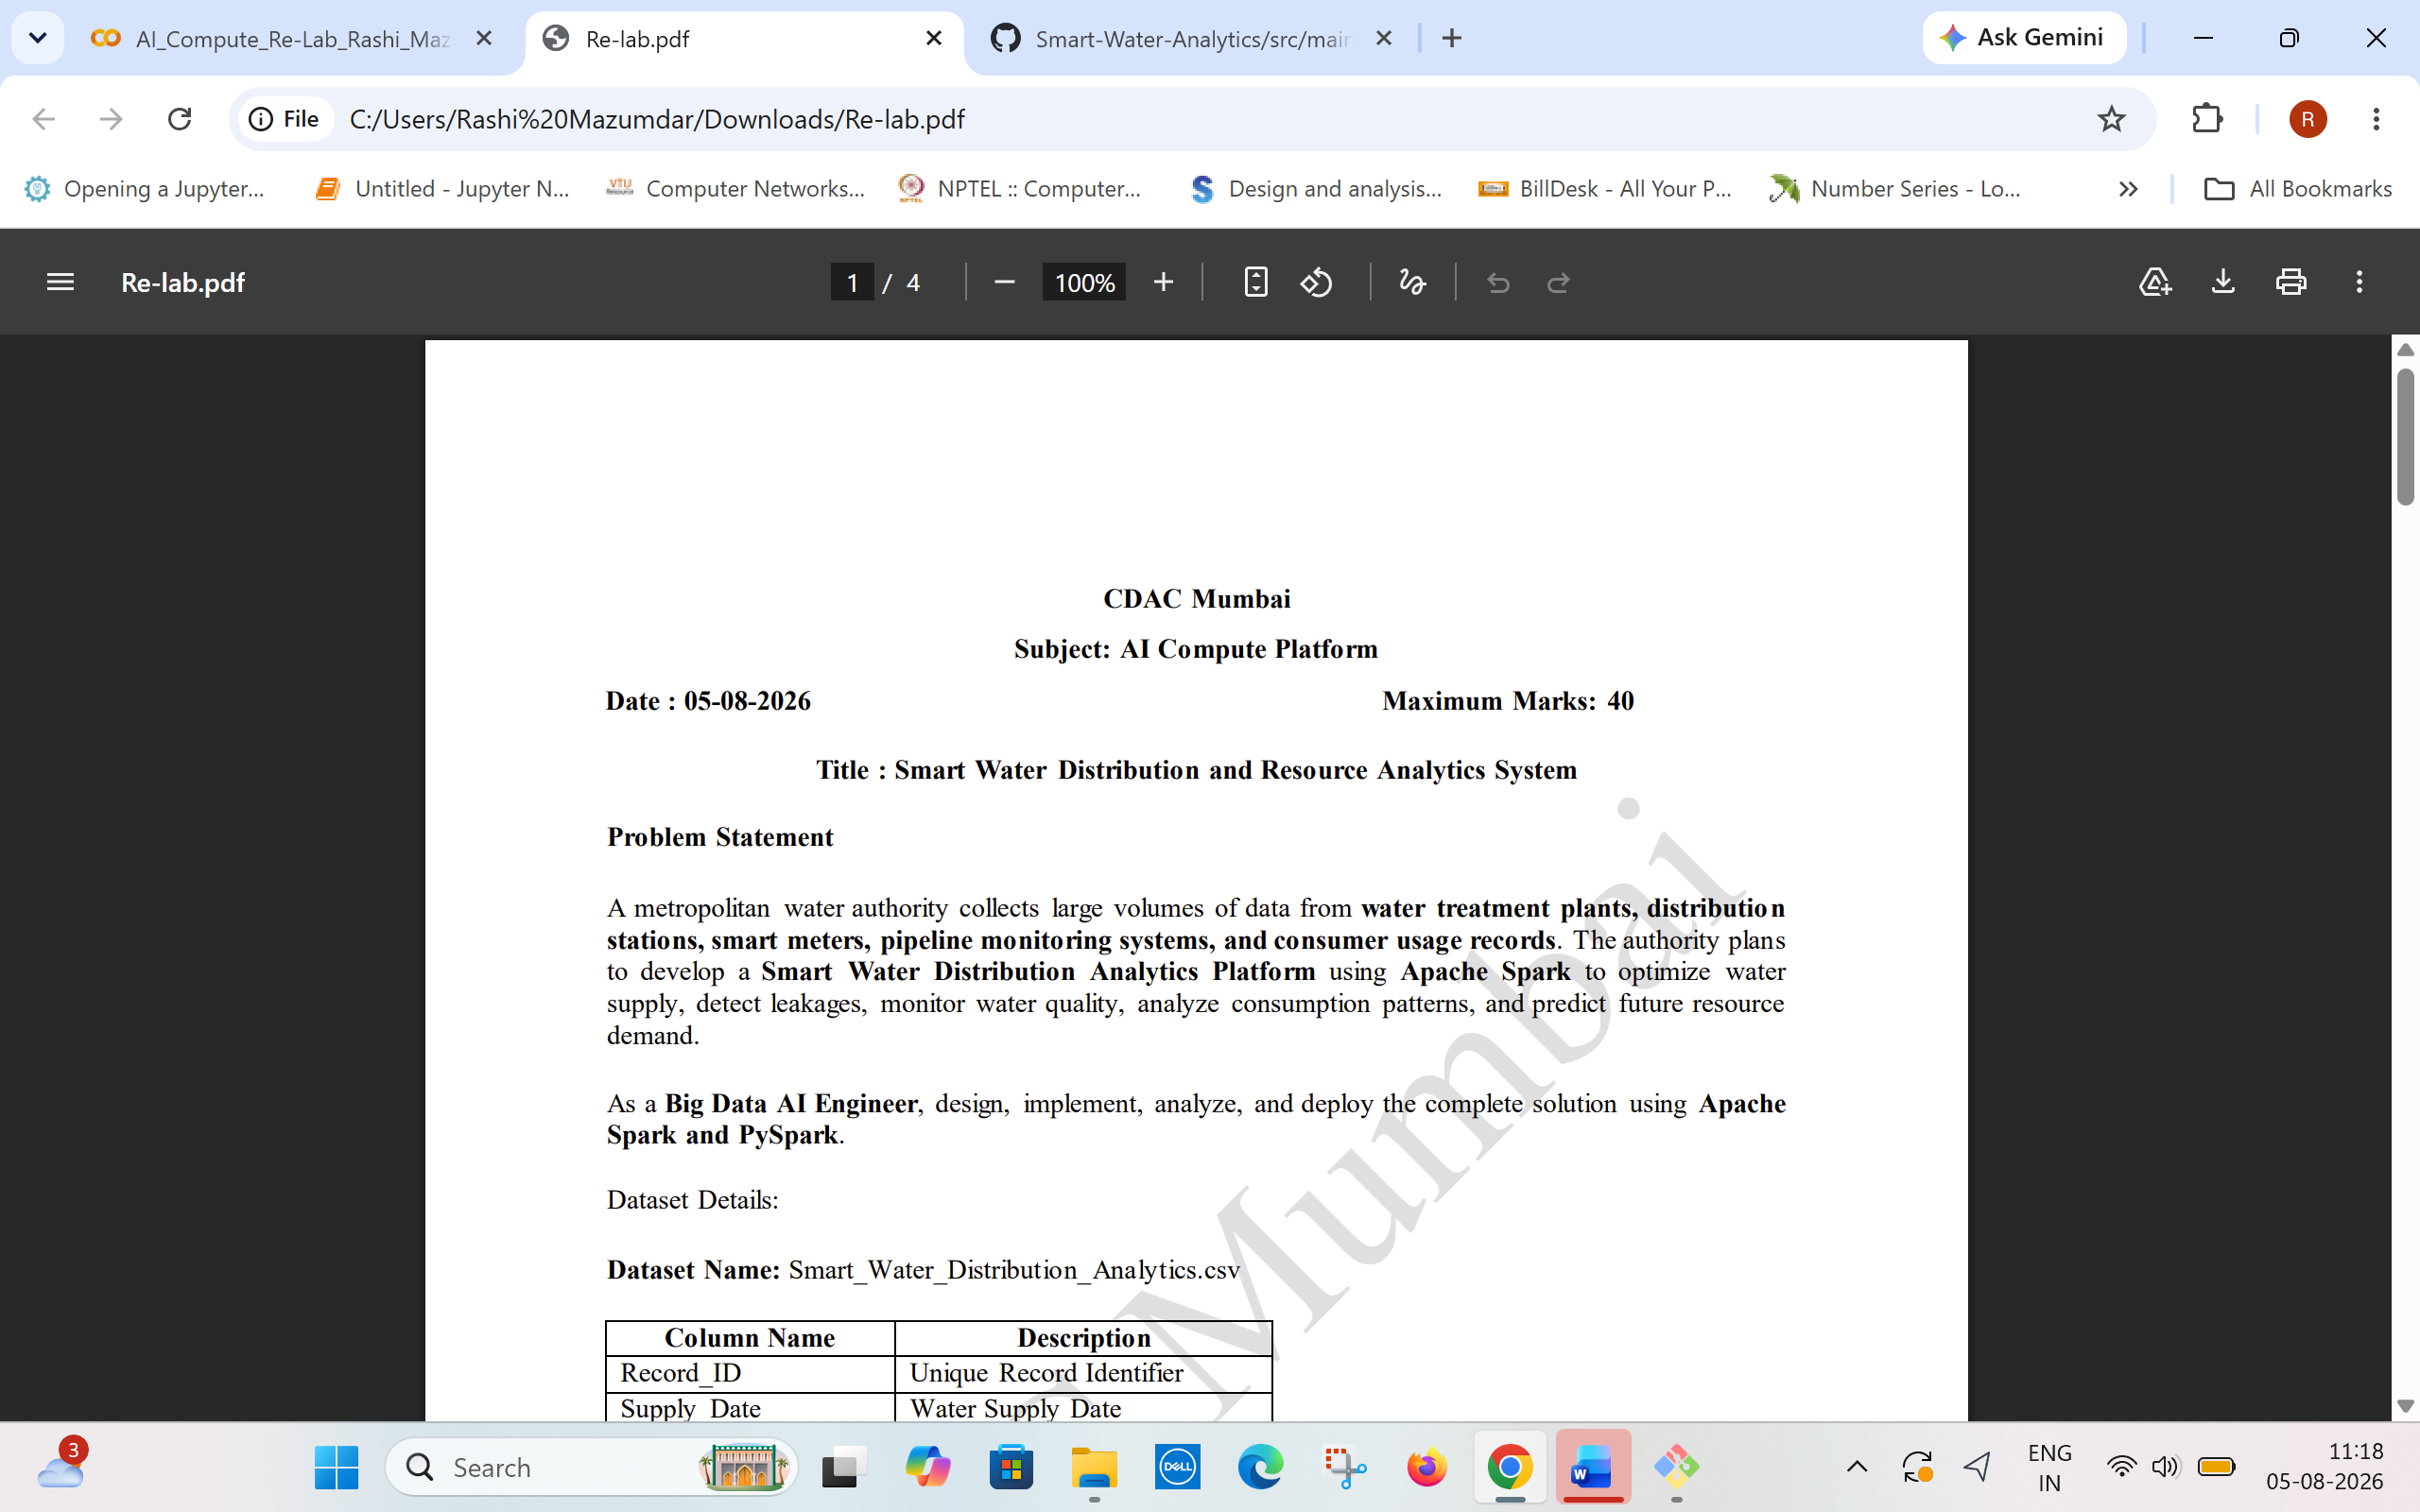

In [5]:
!pip install pyspark

Q1. Spark Environment Setup and Data Loading

In [1]:
# --- Cell 1: Initialize SparkSession and SparkContext ---
from pyspark.sql import SparkSession

# Initialize SparkSession with an application name
spark = SparkSession.builder \
    .appName("Smart Water Distribution Analytics") \
    .getOrCreate()

# Retrieve SparkContext from SparkSession
sc = spark.sparkContext

print("Spark Session initialized successfully.")
print("Spark Context Version:", sc.version)

Spark Session initialized successfully.
Spark Context Version: 4.0.3


In [2]:
# --- Cell 2: Load Dataset, Display Schema, Records, and Count ---
# Load CSV file with headers and automatically infer schema
df = spark.read.csv(
    "/content/sample_data/DataSetAICompuetRelab.csv",
    header=True,
    inferSchema=True
)

# Display Dataset Schema
print("Dataset Schema")
df.printSchema()

# Display First 10 Records
print(" First 10 Records ")
df.show(10, truncate=False)

# Display Total Number of Records
total_records = df.count()
print(f"Total Number of Records: {total_records}")

=== Dataset Schema ===
root
 |-- Record_ID: integer (nullable = true)
 |-- Supply_Date: date (nullable = true)
 |-- Zone: string (nullable = true)
 |-- Distribution_Station: string (nullable = true)
 |-- Water_Source: string (nullable = true)
 |-- Supply_Volume_Liters: double (nullable = true)
 |-- Consumption_Liters: double (nullable = true)
 |-- Water_Loss_Liters: double (nullable = true)
 |-- Pressure_PSI: double (nullable = true)
 |-- Pipeline_ID: string (nullable = true)
 |-- Leakage_Events: integer (nullable = true)
 |-- Water_Quality: string (nullable = true)
 |-- PH_Value: double (nullable = true)
 |-- Turbidity_NTU: double (nullable = true)
 |-- Consumer_Count: integer (nullable = true)
 |-- Maintenance_Cost: double (nullable = true)
 |-- System_Status: string (nullable = true)

=== First 10 Records ===
+---------+-----------+-------+--------------------+--------------+--------------------+------------------+-----------------+------------+-----------+--------------+-----------

In [7]:
# --- Cell 3: Descriptive Statistics of Numerical Attributes ---
# Summary statistics for numerical columns
df.describe([
    "Supply_Volume_Liters",
    "Consumption_Liters",
    "Water_Loss_Liters",
    "Pressure_PSI",
    "Leakage_Events",
    "PH_Value",
    "Turbidity_NTU",
    "Consumer_Count",
    "Maintenance_Cost"
]).show()

+-------+--------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+
|summary|Supply_Volume_Liters|Consumption_Liters| Water_Loss_Liters|      Pressure_PSI|    Leakage_Events|          PH_Value|    Turbidity_NTU|   Consumer_Count|  Maintenance_Cost|
+-------+--------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+
|  count|               10000|             10000|             10000|             10000|             10000|             10000|            10000|            10000|             10000|
|   mean|  105709.42356399984| 86086.21900999984|19623.204553999996|50.061879999999945|            2.4854| 7.504423999999973|5.052497000000008|        2727.4968| 50753.05410699993|
| stddev|   54595.56159590053| 45789.96880588793|15324.337477240319|17.325018224846072|1.724205

Q2. RDD Programming and Transformations


In [6]:
# --- Cell 4: Create RDD and Perform RDD Transformations ---
# Convert PySpark DataFrame to RDD
rdd = df.rdd

# Transformation 1: map() - Extract (Zone, Supply_Volume_Liters)
rdd_map = rdd.map(lambda row: (row["Zone"], float(row["Supply_Volume_Liters"] if row["Supply_Volume_Liters"] else 0)))

# Transformation 2: filter() - Keep records where Supply Volume > 50,000 liters
rdd_filtered = rdd_map.filter(lambda x: x[1] > 50000)

# Transformation 3: flatMap() - Split zone name into individual characters
rdd_flatmap = rdd.flatMap(lambda row: str(row["Zone"]).split())

print("Transformation samples completed successfully.")

Transformation samples completed successfully.


In [8]:
# --- Cell 5: Perform RDD Actions ---
# Action 1: count() - Count total records in filtered RDD
filtered_count = rdd_filtered.count()
print(f"Count of filtered records: {filtered_count}")

# Action 2: collect() - Fetch first 5 elements to driver node
sample_collected = rdd_filtered.take(5)  # Using take for safe collection
print("Sample collected records:", sample_collected)

# Action 3: reduce() - Sum total supply volume across filtered RDD
total_supply = rdd_filtered.map(lambda x: x[1]).reduce(lambda a, b: a + b)
print(f"Total Supply Volume from reduce(): {total_supply:.2f} Liters")

Count of filtered records: 7933
Sample collected records: [('Central', 72854.04), ('North', 163173.87), ('North', 130479.58), ('Central', 87431.83), ('North', 152778.64)]
Total Supply Volume from reduce(): 994365687.30 Liters


In [9]:
# --- Cell 6: Total Water Supplied per Zone using Key-Value Pair RDD ---
# Create Key-Value Pair RDD: Key = Zone, Value = Supply_Volume_Liters
zone_supply_rdd = rdd.map(lambda row: (row["Zone"], float(row["Supply_Volume_Liters"] if row["Supply_Volume_Liters"] else 0)))

# Aggregate supply volume by key (Zone)
zone_total_supply_rdd = zone_supply_rdd.reduceByKey(lambda a, b: a + b)

# Display results
print("Total Water Supplied per Zone:")
for zone, total in zone_total_supply_rdd.collect():
    print(f"Zone: {zone:<15} | Total Supply: {total:,.2f} Liters")

Total Water Supplied per Zone:
Zone: Central         | Total Supply: 210,179,145.88 Liters
Zone: North           | Total Supply: 214,628,262.21 Liters
Zone: South           | Total Supply: 206,422,486.65 Liters
Zone: West            | Total Supply: 214,516,964.20 Liters
Zone: East            | Total Supply: 211,347,376.70 Liters


Q3. Spark DataFrame Operations


In [10]:
# --- Cell 7: Select Specific Columns ---
from pyspark.sql.functions import col, avg, sum as _sum

# Select required columns
df_selected = df.select(
    "Zone",
    "Distribution_Station",
    "Supply_Volume_Liters",
    "Consumption_Liters"
)

df_selected.show(10)

+-------+--------------------+--------------------+------------------+
|   Zone|Distribution_Station|Supply_Volume_Liters|Consumption_Liters|
+-------+--------------------+--------------------+------------------+
|Central|                DS27|            72854.04|           63503.1|
|  North|                DS11|            10989.33|           9112.23|
|  North|                DS11|           163173.87|         150019.45|
|  North|                DS12|           130479.58|         113023.42|
|Central|                DS10|            87431.83|          66273.91|
|  North|                 DS1|           152778.64|         120693.18|
|  North|                DS19|           157997.93|         114399.66|
|  South|                DS14|            69118.79|          59602.42|
|  South|                DS10|           139833.28|         103052.95|
|   West|                DS25|           157212.05|         139306.36|
+-------+--------------------+--------------------+------------------+
only s

In [11]:
# --- Cell 8: Filter Records ---
# Filter: Water Loss > 1000 Liters AND Leakage Events > 2
df_filtered = df.filter(
    (col("Water_Loss_Liters") > 1000) &
    (col("Leakage_Events") > 2)
)

df_filtered.show(10)

+---------+-----------+-------+--------------------+--------------+--------------------+------------------+-----------------+------------+-----------+--------------+-------------+--------+-------------+--------------+----------------+-------------+
|Record_ID|Supply_Date|   Zone|Distribution_Station|  Water_Source|Supply_Volume_Liters|Consumption_Liters|Water_Loss_Liters|Pressure_PSI|Pipeline_ID|Leakage_Events|Water_Quality|PH_Value|Turbidity_NTU|Consumer_Count|Maintenance_Cost|System_Status|
+---------+-----------+-------+--------------------+--------------+--------------------+------------------+-----------------+------------+-----------+--------------+-------------+--------+-------------+--------------+----------------+-------------+
|        1| 2026-01-25|Central|                DS27|TreatmentPlant|            72854.04|           63503.1|          9350.94|        59.3|       P480|             4|    Excellent|    7.52|         5.49|          3240|        91535.33|       Normal|
|   

In [12]:
# --- Cell 9: Sort Records ---
# Sort records based on Water Loss in descending order
df_sorted = df.sort(col("Water_Loss_Liters").desc())

df_sorted.show(10)

+---------+-----------+-------+--------------------+--------------+--------------------+------------------+-----------------+------------+-----------+--------------+-------------+--------+-------------+--------------+----------------+-------------+
|Record_ID|Supply_Date|   Zone|Distribution_Station|  Water_Source|Supply_Volume_Liters|Consumption_Liters|Water_Loss_Liters|Pressure_PSI|Pipeline_ID|Leakage_Events|Water_Quality|PH_Value|Turbidity_NTU|Consumer_Count|Maintenance_Cost|System_Status|
+---------+-----------+-------+--------------------+--------------+--------------------+------------------+-----------------+------------+-----------+--------------+-------------+--------+-------------+--------------+----------------+-------------+
|     5050| 2026-01-29|  North|                 DS9|         River|           199219.82|         130483.63|         68736.19|        23.5|       P731|             1|    Excellent|    8.31|         9.85|          1584|        65171.69|       Normal|
|   

In [13]:
# --- Cell 10: Group by Zone and Calculate Aggregations ---
# Group by Zone and compute total supply/consumption/loss and average pressure/maintenance cost
df_zone_metrics = df.groupBy("Zone").agg(
    _sum("Supply_Volume_Liters").alias("Total_Water_Supplied"),
    _sum("Consumption_Liters").alias("Total_Water_Consumed"),
    _sum("Water_Loss_Liters").alias("Total_Water_Loss"),
    avg("Pressure_PSI").alias("Avg_Pipeline_Pressure"),
    avg("Maintenance_Cost").alias("Avg_Maintenance_Cost")
)

df_zone_metrics.show()

+-------+--------------------+--------------------+-------------------+---------------------+--------------------+
|   Zone|Total_Water_Supplied|Total_Water_Consumed|   Total_Water_Loss|Avg_Pipeline_Pressure|Avg_Maintenance_Cost|
+-------+--------------------+--------------------+-------------------+---------------------+--------------------+
|  South|2.0642248665000013E8| 1.668846068800003E8|3.953787977000007E7|   50.380253164556926|   52108.16070886062|
|Central|2.1017914588000005E8| 1.712170387399998E8|3.896210713999991E7|    50.11089258698945|   51126.89768028241|
|   East|2.1134737670000002E8|      1.7249534199E8|3.885203470999998E7|    50.15527763881939|   50354.88592796408|
|   West|2.1451696420000035E8|1.7504741414000028E8|3.946955005999999E7|   50.432172633643944|  49659.052594409026|
|  North|2.1462826221000025E8|1.7521778835000008E8|3.941047385999994E7|   49.229690618762454|  50557.914351297404|
+-------+--------------------+--------------------+-------------------+---------

Q4. Exploratory Data Analysis using Spark SQL


In [14]:
# --- Cell 11: Register Temporary View ---
# Create or replace a temporary view for SQL querying
df.createOrReplaceTempView("water_data")
print("Temporary view 'water_data' created.")

Temporary view 'water_data' created.


In [15]:
# --- Cell 12: Q4(a) Top 5 Zones with Maximum Water Consumption ---
spark.sql("""
    SELECT Zone, SUM(Consumption_Liters) AS Total_Consumption
    FROM water_data
    GROUP BY Zone
    ORDER BY Total_Consumption DESC
    LIMIT 5
""").show()

+-------+--------------------+
|   Zone|   Total_Consumption|
+-------+--------------------+
|  North|1.7521778835000008E8|
|   West|1.7504741414000028E8|
|   East|      1.7249534199E8|
|Central| 1.712170387399998E8|
|  South| 1.668846068800003E8|
+-------+--------------------+



In [16]:
# --- Cell 13: Q4(b) Zone-wise Water Loss Statistics ---
spark.sql("""
    SELECT
        Zone,
        SUM(Water_Loss_Liters) AS Total_Loss,
        AVG(Water_Loss_Liters) AS Avg_Loss,
        MAX(Water_Loss_Liters) AS Max_Loss,
        MIN(Water_Loss_Liters) AS Min_Loss
    FROM water_data
    GROUP BY Zone
    ORDER BY Total_Loss DESC
""").show()

+-------+-------------------+------------------+--------+--------+
|   Zone|         Total_Loss|          Avg_Loss|Max_Loss|Min_Loss|
+-------+-------------------+------------------+--------+--------+
|  South|3.953787977000007E7|20019.179630379782| 68634.1|  224.99|
|   West|3.946955005999999E7|19357.307533104457|68575.26|   435.6|
|  North|3.941047385999994E7| 19665.90511976045|68736.19|  321.72|
|Central|3.896210713999991E7|19648.062097831524|68037.43|  294.26|
|   East|3.885203470999998E7|19435.735222611296|68424.59|  391.97|
+-------+-------------------+------------------+--------+--------+



In [17]:
# --- Cell 14: Q4(c) Distribution Station Efficiency ---
# Efficiency = (Consumption / Supply) * 100
spark.sql("""
    SELECT
        Distribution_Station,
        SUM(Supply_Volume_Liters) AS Total_Supply,
        SUM(Consumption_Liters) AS Total_Consumption,
        ROUND((SUM(Consumption_Liters) / SUM(Supply_Volume_Liters)) * 100, 2) AS Efficiency_Percentage
    FROM water_data
    GROUP BY Distribution_Station
    ORDER BY Efficiency_Percentage DESC
""").show()

+--------------------+--------------------+--------------------+---------------------+
|Distribution_Station|        Total_Supply|   Total_Consumption|Efficiency_Percentage|
+--------------------+--------------------+--------------------+---------------------+
|                DS18| 3.386100188999999E7|2.8021387420000006E7|                82.75|
|                DS21| 3.634265483999998E7|3.0061225200000014E7|                82.72|
|                DS20|3.2946705250000026E7|2.7198785549999997E7|                82.55|
|                DS13| 3.738985428999997E7|3.0751755980000008E7|                82.25|
|                DS26| 3.713631459000002E7|       3.052349776E7|                82.19|
|                DS12|       3.493737812E7| 2.871620294000001E7|                82.19|
|                DS15| 3.643554985999999E7|2.9921707709999982E7|                82.12|
|                 DS9|3.3595343290000014E7|2.7578700790000014E7|                82.09|
|                 DS2| 3.479295347999999E7|

In [18]:
# --- Cell 15: Q4(d) Monthly Water Supply Trends ---
spark.sql("""
    SELECT
        DATE_FORMAT(TO_DATE(Supply_Date, 'yyyy-MM-dd'), 'yyyy-MM') AS Year_Month,
        SUM(Supply_Volume_Liters) AS Monthly_Supply
    FROM water_data
    GROUP BY Year_Month
    ORDER BY Year_Month
""").show()

+----------+--------------------+
|Year_Month|      Monthly_Supply|
+----------+--------------------+
|   2026-01| 1.759291433300001E8|
|   2026-02|1.5768824718000016E8|
|   2026-03|1.8448445542999986E8|
|   2026-04| 1.810309662200003E8|
|   2026-05|1.7895177555000037E8|
|   2026-06|1.7900964792999995E8|
+----------+--------------------+



In [19]:
# --- Cell 16: Q4(e) Monthly Water Consumption Trends ---
spark.sql("""
    SELECT
        DATE_FORMAT(TO_DATE(Supply_Date, 'yyyy-MM-dd'), 'yyyy-MM') AS Year_Month,
        SUM(Consumption_Liters) AS Monthly_Consumption
    FROM water_data
    GROUP BY Year_Month
    ORDER BY Year_Month
""").show()

+----------+--------------------+
|Year_Month| Monthly_Consumption|
+----------+--------------------+
|   2026-01| 1.435833950699999E8|
|   2026-02|1.2768821915000013E8|
|   2026-03|1.4976594985999998E8|
|   2026-04|1.4759754209999993E8|
|   2026-05| 1.461438116700001E8|
|   2026-06|1.4608327225000006E8|
+----------+--------------------+



In [20]:
# --- Cell 17: Q4(f) Zones with Maximum Leakage Events ---
spark.sql("""
    SELECT Zone, SUM(Leakage_Events) AS Total_Leakage_Events
    FROM water_data
    GROUP BY Zone
    ORDER BY Total_Leakage_Events DESC
""").show()

+-------+--------------------+
|   Zone|Total_Leakage_Events|
+-------+--------------------+
|   West|                5036|
|  South|                4999|
|  North|                4975|
|   East|                4964|
|Central|                4880|
+-------+--------------------+



In [21]:
# --- Cell 18: Q4(g) Average pH Value and Turbidity by Water Source ---
spark.sql("""
    SELECT
        Water_Source,
        ROUND(AVG(PH_Value), 2) AS Avg_PH,
        ROUND(AVG(Turbidity_NTU), 2) AS Avg_Turbidity
    FROM water_data
    GROUP BY Water_Source
""").show()

+--------------+------+-------------+
|  Water_Source|Avg_PH|Avg_Turbidity|
+--------------+------+-------------+
|     Reservoir|  7.51|         5.16|
|TreatmentPlant|  7.51|         5.05|
|   Groundwater|  7.49|         4.95|
|         River|  7.51|         5.05|
+--------------+------+-------------+



Q5. ETL Pipeline Development


In [23]:
# --- Cell 19: ETL Pipeline Implementation ---
from pyspark.sql.functions import col, to_date

def run_etl_pipeline(input_path: str, output_path: str):
    # Step 1: Extract
    df_raw = spark.read.csv(input_path, header=True, inferSchema=True)

    # Step 2: Remove Duplicates
    df_dedup = df_raw.dropDuplicates(["Record_ID"])

    # Step 3: Handle Missing Values
    # Fill numeric nulls with mean/0, string nulls with 'Unknown'
    df_cleaned = df_dedup.na.fill({
        "Supply_Volume_Liters": 0,
        "Consumption_Liters": 0,
        "Water_Loss_Liters": 0,
        "Pressure_PSI": 0.0,
        "Leakage_Events": 0,
        "Water_Quality": "Unknown",
        "System_Status": "Unknown"
    })

    # Step 4: Data Type Conversions
    df_transformed = df_cleaned \
        .withColumn("Supply_Date", to_date(col("Supply_Date"), "yyyy-MM-dd")) \
        .withColumn("Supply_Volume_Liters", col("Supply_Volume_Liters").cast("double")) \
        .withColumn("Consumption_Liters", col("Consumption_Liters").cast("double")) \
        .withColumn("Water_Loss_Liters", col("Water_Loss_Liters").cast("double")) \
        .withColumn("Pressure_PSI", col("Pressure_PSI").cast("double")) \
        .withColumn("Leakage_Events", col("Leakage_Events").cast("integer")) \
        .withColumn("PH_Value", col("PH_Value").cast("double")) \
        .withColumn("Turbidity_NTU", col("Turbidity_NTU").cast("double")) \
        .withColumn("Consumer_Count", col("Consumer_Count").cast("integer")) \
        .withColumn("Maintenance_Cost", col("Maintenance_Cost").cast("double"))

    # Step 5: Save to Parquet format
    df_transformed.write.mode("overwrite").parquet(output_path)
    print(f"ETL pipeline executed successfully. Output saved to {output_path}")

# Run the pipeline
run_etl_pipeline("/content/sample_data/DataSetAICompuetRelab.csv", "processed_water_data.parquet")

ETL pipeline executed successfully. Output saved to processed_water_data.parquet


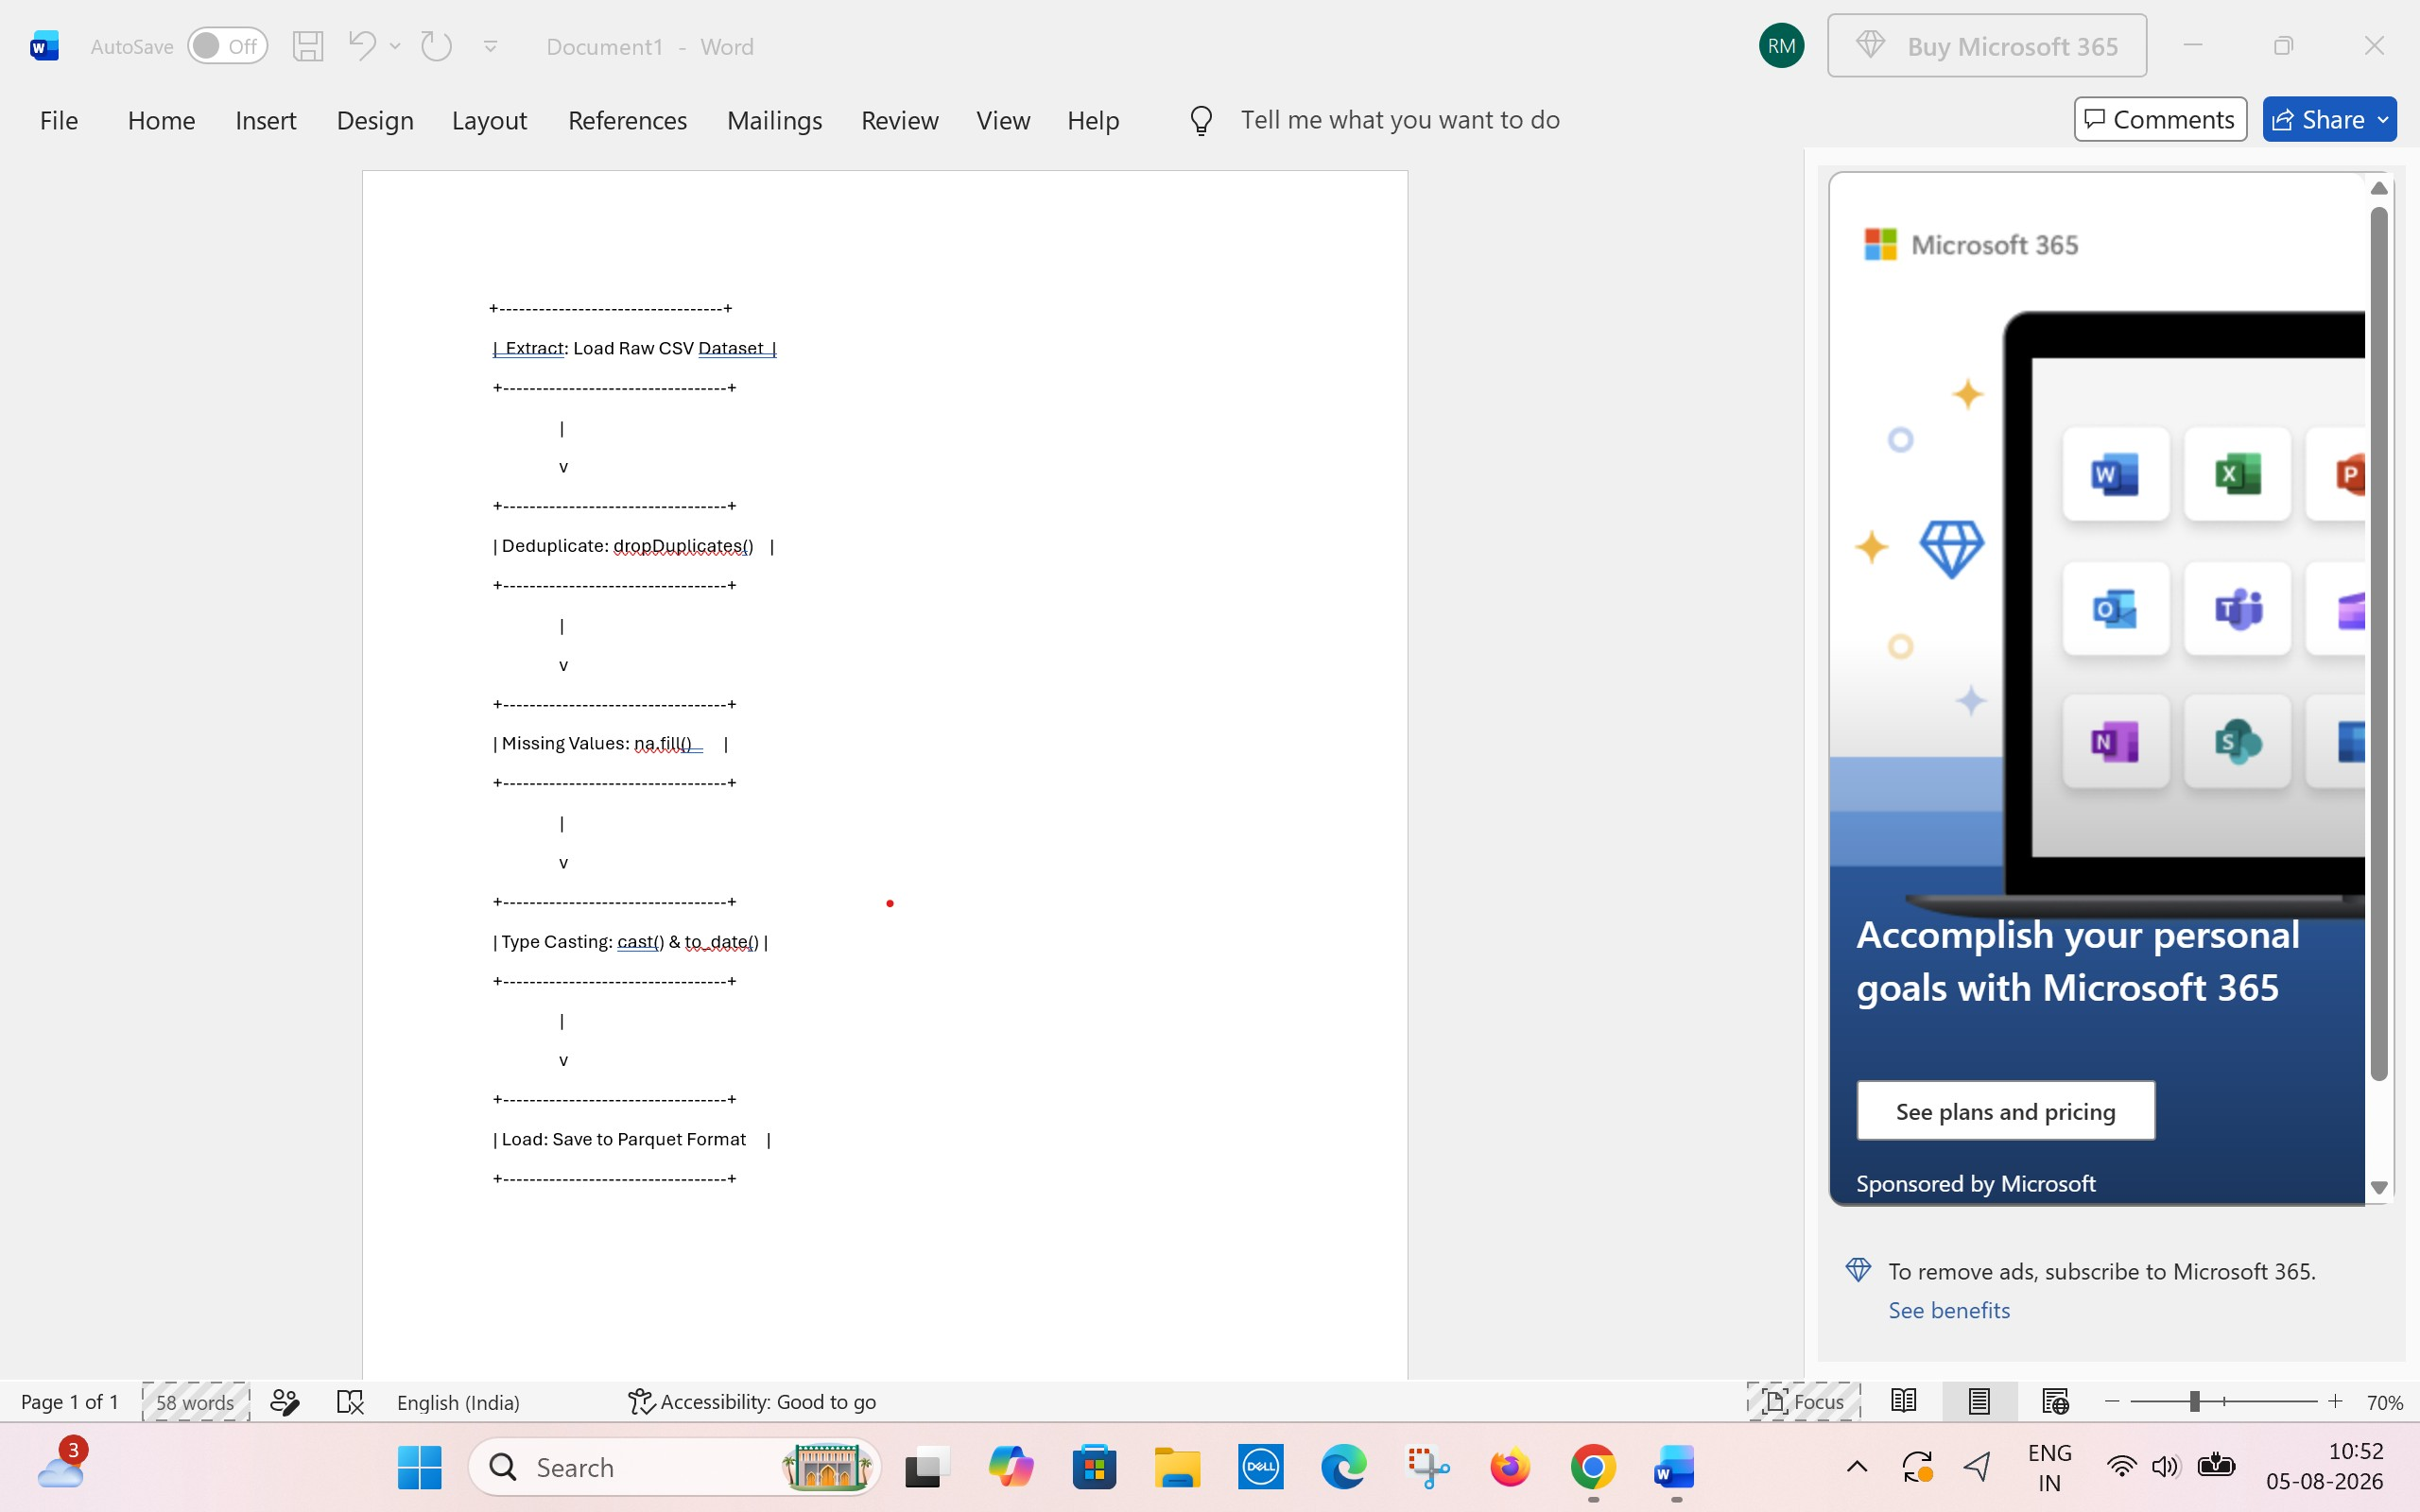

Q6. Machine Learning using Spark MLlib


Option A — Predict Future Water Consumption Demand

In [24]:
# --- Cell 20: Spark MLlib Model Pipeline ---
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Step 1: Feature Selection & Categorical Indexing
indexer = StringIndexer(inputCol="Zone", outputCol="Zone_Index", handleInvalid="keep")
df_ml = indexer.fit(df).transform(df)

feature_cols = [
    "Zone_Index",
    "Supply_Volume_Liters",
    "Pressure_PSI",
    "Consumer_Count",
    "Maintenance_Cost"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data_prepared = assembler.transform(df_ml).select("features", col("Consumption_Liters").alias("label"))

# Step 2: Train/Test Split
train_data, test_data = data_prepared.randomSplit([0.8, 0.2], seed=42)

# Step 3: Model Training
lr = LinearRegression(featuresCol="features", labelCol="label")
model = lr.fit(train_data)

# Step 4: Prediction
predictions = model.transform(test_data)
predictions.select("features", "label", "prediction").show(5)

# Step 5: Performance Evaluation
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("=== Model Evaluation ===")
print(f"Evaluation Metric (RMSE): {rmse:.2f}")
print(f"Evaluation Metric (R2 Score): {r2:.4f}")

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|[0.0,10379.89,46....| 7279.28| 9270.273551376398|
|[0.0,10992.17,62....| 8956.82| 9422.414739962473|
|[0.0,11224.81,31....| 10434.3|10289.095844496826|
|[0.0,11520.58,66....| 8264.83| 9967.691870790084|
|[0.0,11949.22,25....|11513.62|10486.778793183652|
+--------------------+--------+------------------+
only showing top 5 rows
=== Model Evaluation ===
Evaluation Metric (RMSE): 11375.42
Evaluation Metric (R2 Score): 0.9387


Q7. Deployment using DevOps Tools


a) GitHub Repository Setup Commands

# Initialize git repository
git init smart-water-analytics

# Navigate into directory
cd smart-water-analytics

# Create project structure
mkdir -p src tests config .github/workflows

# Add code files
touch src/main.py requirements.txt README.md .gitignore

# Stage and commit files
git add .
git commit -m "Initial commit: Smart Water Analytics PySpark platform"

# Link to remote GitHub repository and push
git remote add origin https://github.com/RashiMazumdar08/Smart-Water-Analytics.git
git branch -M main
git push -u origin main

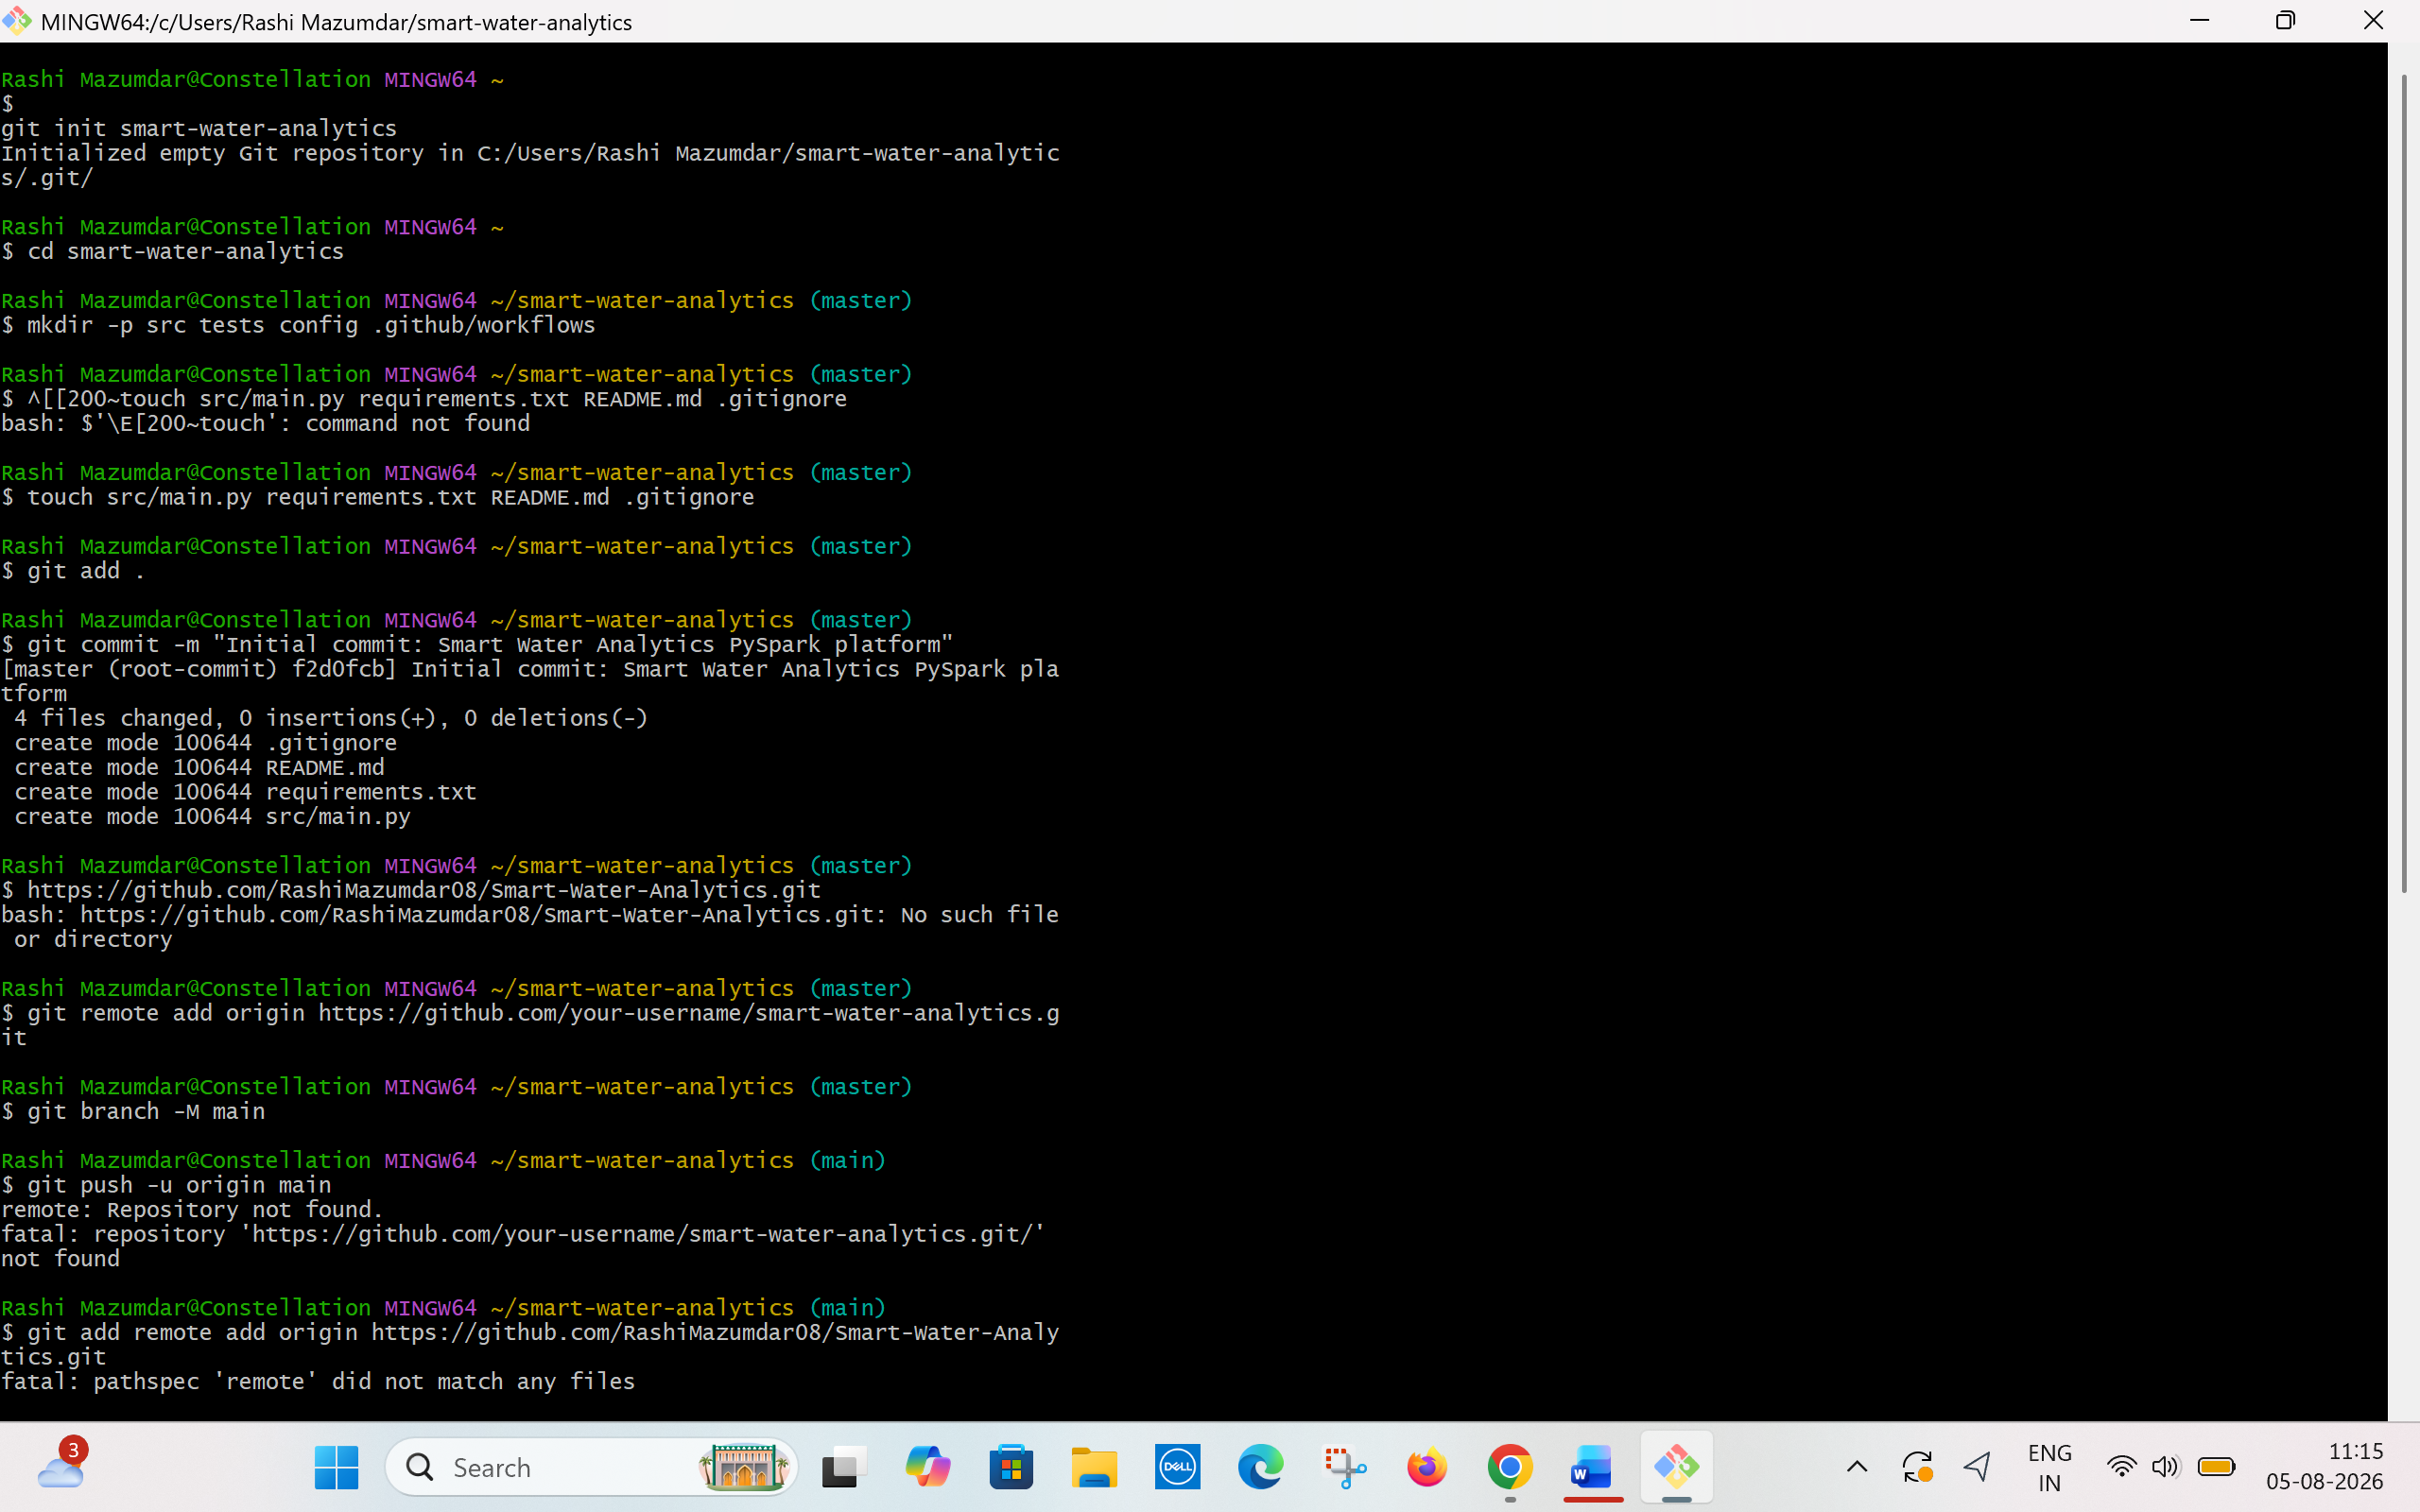

b) CI/CD Pipeline using GitHub Actions

Create .github/workflows/ci_cd_pipeline.yml:

name: PySpark Water Analytics CI/CD Pipeline

on:
  push:
    branches: [ "main" ]
  pull_request:
    branches: [ "main" ]

jobs:
  build-and-test:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout Code Repository
      uses: actions/checkout@v3

    - name: Set up Python Environment
      uses: actions/setup-python@v4
      with:
        python-version: '3.10'

    - name: Install Java (Required for PySpark)
      uses: actions/setup-java@v3
      with:
        distribution: 'temurin'
        java-version: '17'

    - name: Install Dependencies
      run: |
        python -m pip install --upgrade pip
        pip install pyspark pytest

    - name: Run Code Linting & Syntax Check
      run: |
        python -m py_compile src/main.py

    - name: Execute Unit Tests
      run: |
        pytest tests/

    - name: Deploy Artifact Notification
      run: |
        echo "Build and integration testing successfully completed."